In [ ]:
import subprocess, sys, importlib

def _sh(cmd):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def _need(mod):
    try:
        importlib.import_module(mod)
        return False
    except ImportError:
        return True

if _need("augly"):
    _sh("apt-get -qq install -y libmagic1 > /dev/null 2>&1")
    _sh(f'"{sys.executable}" -m pip install -q --no-deps augly')
    _sh(f'"{sys.executable}" -m pip install -q "iopath>=0.1.8" "python-magic>=0.4.22" '
        f'"regex>=2021.4.4" "nlpaug==1.1.3"')

import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter

for _name, _builtin in (("float", float), ("int", int), ("bool", bool)):
    if not hasattr(np, _name):
        setattr(np, _name, _builtin)

def _size(font, text):
    left, top, right, bottom = font.getbbox(text)
    return (right, bottom)

if not hasattr(ImageFont.FreeTypeFont, "getsize"):
    ImageFont.FreeTypeFont.getsize = lambda self, t, *a, **k: _size(self, t)

if not hasattr(ImageFont.FreeTypeFont, "getsize_multiline"):
    def _getsize_multiline(self, text, direction=None, spacing=4, features=None,
                           language=None, stroke_width=0):
        lines = text.split("\n")
        w = max((_size(self, ln)[0] for ln in lines), default=0)
        h = sum(_size(self, ln)[1] for ln in lines) + spacing * (len(lines) - 1)
        return (w, h)
    ImageFont.FreeTypeFont.getsize_multiline = _getsize_multiline

import os, io, json, math, random, string, textwrap, unicodedata, warnings
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import pandas as pd

import augly.image as imaugs
import augly.text as textaugs
import augly.utils as augutils
from augly.image.transforms import BaseTransform as ImageBaseTransform

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)

print("\n" + "=" * 78)
print("AugLy ready.  assets at:", augutils.ASSETS_BASE_DIR)
print("image augs :", len([f for f in dir(imaugs) if f[0].islower()]))
print("text  augs :", len([f for f in dir(textaugs) if f[0].islower()]))
print("=" * 78 + "\n")

def make_image(idx: int, w: int = 320, h: int = 240) -> Tuple[Image.Image, Tuple[int, int, int, int]]:
    """Procedurally generated 'photo' + a ground-truth bbox in pascal_voc format."""
    rng = random.Random(SEED + idx)
    img = Image.new("RGB", (w, h), tuple(rng.randint(20, 90) for _ in range(3)))
    d = ImageDraw.Draw(img)

    for _ in range(70):
        x0, y0 = rng.randint(0, w), rng.randint(0, h)
        d.line([x0, y0, x0 + rng.randint(-60, 60), y0 + rng.randint(-60, 60)],
               fill=tuple(rng.randint(60, 160) for _ in range(3)), width=rng.randint(1, 3))

    ow, oh = rng.randint(70, 130), rng.randint(60, 110)
    ox, oy = rng.randint(10, w - ow - 10), rng.randint(10, h - oh - 10)
    box = (ox, oy, ox + ow, oy + oh)
    colour = tuple(rng.randint(150, 255) for _ in range(3))
    if idx % 3 == 0:
        d.ellipse(box, fill=colour, outline=(255, 255, 255), width=3)
    elif idx % 3 == 1:
        d.rectangle(box, fill=colour, outline=(255, 255, 255), width=3)
    else:
        d.polygon([(ox + ow // 2, oy), (ox + ow, oy + oh), (ox, oy + oh)],
                  fill=colour, outline=(255, 255, 255))
    return img, box

N_IMAGES = 24
IMAGES, BOXES = zip(*[make_image(i) for i in range(N_IMAGES)])
IMAGES, BOXES = list(IMAGES), list(BOXES)
DEMO_IMG, DEMO_BOX = IMAGES[0], BOXES[0]

def make_text_dataset(n_per_class: int = 260):
    """Tiny sentiment corpus built from templates -> learnable but not trivial."""
    rng = random.Random(SEED)
    pos_adj = ["excellent", "delightful", "superb", "charming", "brilliant",
               "flawless", "wonderful", "outstanding", "impressive", "lovely"]
    neg_adj = ["terrible", "awful", "dreadful", "disappointing", "clumsy",
               "broken", "miserable", "useless", "painful", "sloppy"]
    subj = ["the movie", "this restaurant", "the hotel room", "their support team",
            "the new phone", "the sequel", "this laptop", "the delivery service"]
    tail_p = ["and I would recommend it to anyone", "worth every rupee",
              "I left completely satisfied", "easily the best of the year",
              "it exceeded all my expectations"]
    tail_n = ["and I want a refund", "a total waste of money",
              "I left extremely frustrated", "easily the worst of the year",
              "it failed every expectation"]
    rows = []
    for _ in range(n_per_class):
        rows.append((f"{rng.choice(subj)} was {rng.choice(pos_adj)} {rng.choice(tail_p)}", 1))
        rows.append((f"{rng.choice(subj)} was {rng.choice(neg_adj)} {rng.choice(tail_n)}", 0))
    rng.shuffle(rows)
    return [r[0] for r in rows], [r[1] for r in rows]

TEXTS, LABELS = make_text_dataset()
DEMO_TEXT = "The quick brown fox jumps over the lazy dog near the river bank"

def make_audio(seconds: float = 2.0, sr: int = 16000) -> Tuple[np.ndarray, int]:
    """A chirp + harmonics + a little noise = something you can actually hear change."""
    t = np.linspace(0, seconds, int(sr * seconds), endpoint=False)
    f = np.linspace(220, 880, t.size)
    sig = 0.5 * np.sin(2 * np.pi * f * t) + 0.2 * np.sin(2 * np.pi * 2 * f * t)
    sig += 0.02 * np.random.RandomState(SEED).randn(t.size)
    env = np.minimum(1.0, np.minimum(t * 8, (seconds - t) * 8))
    return (sig * env).astype(np.float32), sr

AUDIO, SR = make_audio()

def show_grid(pairs, cols=4, title="", figsize_scale=2.9):
    """pairs: list of (caption, PIL.Image)."""
    rows = math.ceil(len(pairs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_scale, rows * figsize_scale))
    axes = np.atleast_1d(axes).ravel()
    for ax, (cap, im) in zip(axes, pairs):
        ax.imshow(im)
        ax.set_title(cap, fontsize=8)
        ax.axis("off")
    for ax in axes[len(pairs):]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=13, y=1.0)
    plt.tight_layout()
    plt.show()

def as_str(out) -> str:
    """AugLy text augs return str for str input in some transforms, list in others."""
    return out[0] if isinstance(out, list) else out

print("\n### §2  IMAGE AUGMENTATION + METADATA " + "#" * 38)

functional_result = imaugs.pixelization(DEMO_IMG, ratio=0.25)
class_result = imaugs.Pixelization(ratio=0.25, p=1.0)(DEMO_IMG)
print("functional == class:", np.array_equal(np.array(functional_result), np.array(class_result)))

IMAGE_ZOO = {
    "blur":               lambda im, m: imaugs.blur(im, radius=3.0, metadata=m),
    "brightness":         lambda im, m: imaugs.brightness(im, factor=1.7, metadata=m),
    "color_jitter":       lambda im, m: imaugs.color_jitter(im, brightness_factor=1.3,
                                                            contrast_factor=1.4,
                                                            saturation_factor=1.6, metadata=m),
    "crop":               lambda im, m: imaugs.crop(im, x1=.15, y1=.15, x2=.85, y2=.85, metadata=m),
    "encoding_quality":   lambda im, m: imaugs.encoding_quality(im, quality=8, metadata=m),
    "grayscale":          lambda im, m: imaugs.grayscale(im, metadata=m),
    "hflip":              lambda im, m: imaugs.hflip(im, metadata=m),
    "meme_format":        lambda im, m: imaugs.meme_format(im, text="TOP TEXT",
                                                           caption_height=90, metadata=m),
    "opacity":            lambda im, m: imaugs.opacity(im, level=0.45, metadata=m),
    "overlay_emoji":      lambda im, m: imaugs.overlay_emoji(im, opacity=0.9,
                                                             emoji_size=0.35, metadata=m),
    "overlay_screenshot": lambda im, m: imaugs.overlay_onto_screenshot(im, metadata=m),
    "overlay_stripes":    lambda im, m: imaugs.overlay_stripes(im, line_width=0.4,
                                                               line_opacity=0.7, metadata=m),
    "overlay_text":       lambda im, m: imaugs.overlay_text(im, opacity=0.9, metadata=m),
    "pad_square":         lambda im, m: imaugs.pad_square(im, metadata=m),
    "perspective":        lambda im, m: imaugs.perspective_transform(im, sigma=40.0, metadata=m),
    "pixelization":       lambda im, m: imaugs.pixelization(im, ratio=0.15, metadata=m),
    "random_noise":       lambda im, m: imaugs.random_noise(im, var=0.03, metadata=m),
    "rotate":             lambda im, m: imaugs.rotate(im, degrees=17, metadata=m),
    "saturation":         lambda im, m: imaugs.saturation(im, factor=3.0, metadata=m),
    "scale":              lambda im, m: imaugs.scale(im, factor=0.35, metadata=m),
    "sharpen":            lambda im, m: imaugs.sharpen(im, factor=8.0, metadata=m),
    "shuffle_pixels":     lambda im, m: imaugs.shuffle_pixels(im, factor=0.15, metadata=m),
    "skew":               lambda im, m: imaugs.skew(im, skew_factor=0.35, metadata=m),
    "vflip":              lambda im, m: imaugs.vflip(im, metadata=m),
}

gallery, image_meta = [("ORIGINAL", DEMO_IMG)], []
for name, fn in IMAGE_ZOO.items():
    m = []
    try:
        out = fn(DEMO_IMG, m)
        gallery.append((f"{name}\nintensity={m[0]['intensity']:.1f}", out))
        image_meta.append(m[0])
    except Exception as e:
        print(f"  [skip] {name}: {type(e).__name__}: {e}")

show_grid(gallery, cols=5, title="§2  AugLy image augmentations (with AugLy's own intensity score)")

meta_df = pd.DataFrame(image_meta)[["name", "intensity", "src_width", "src_height",
                                    "dst_width", "dst_height"]]
print(meta_df.sort_values("intensity", ascending=False).head(10).to_string(index=False))

In [ ]:
print("\n### §3  COMPOSITION & REPRODUCIBILITY " + "#" * 39)

REUPLOAD_PIPELINE = imaugs.Compose([
    imaugs.OneOf([
        imaugs.OverlayOntoScreenshot(),
        imaugs.MemeFormat(text="LOL", caption_height=80),
        imaugs.OverlayStripes(line_width=0.3, line_opacity=0.5),
    ], p=0.9),
    imaugs.RandomAspectRatio(min_ratio=0.7, max_ratio=1.4, p=0.5),
    imaugs.RandomEmojiOverlay(p=0.7),
    imaugs.RandomBrightness(min_factor=0.7, max_factor=1.4, p=0.6),
    imaugs.EncodingQuality(quality=12, p=1.0),
])

def run_pipeline(img, seed=None):
    """AugLy image transforms use the global `random` module -> seed it for determinism."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    meta = []
    return REUPLOAD_PIPELINE(img, metadata=meta), meta

a, meta_a = run_pipeline(DEMO_IMG, seed=7)
b, meta_b = run_pipeline(DEMO_IMG, seed=7)
c, _ = run_pipeline(DEMO_IMG, seed=99)
print("same seed -> identical output:", np.array_equal(np.array(a), np.array(b)))
print("applied chain (seed=7)      :", " -> ".join(m["name"] for m in meta_a))
show_grid([("original", DEMO_IMG), ("seed=7", a), ("seed=7 again", b), ("seed=99", c)],
          cols=4, title="§3  Seeded, reproducible augmentation pipelines")

print("\n### §4  BBOX-AWARE AUGMENTATION " + "#" * 45)

BBOX_OPS = [
    ("crop",        lambda im, m, bb: imaugs.crop(im, x1=.1, y1=.1, x2=.9, y2=.9,
                                                  metadata=m, bboxes=bb, bbox_format="pascal_voc")),
    ("hflip",       lambda im, m, bb: imaugs.hflip(im, metadata=m, bboxes=bb,
                                                   bbox_format="pascal_voc")),
    ("rotate 20",   lambda im, m, bb: imaugs.rotate(im, degrees=20, metadata=m, bboxes=bb,
                                                    bbox_format="pascal_voc")),
    ("pad",         lambda im, m, bb: imaugs.pad(im, w_factor=0.25, h_factor=0.25,
                                                 metadata=m, bboxes=bb, bbox_format="pascal_voc")),
    ("meme_format", lambda im, m, bb: imaugs.meme_format(im, text="BOXED", caption_height=80,
                                                         metadata=m, bboxes=bb,
                                                         bbox_format="pascal_voc")),
]

def draw_box(img, box, colour=(0, 255, 0)):
    out = img.copy().convert("RGB")
    ImageDraw.Draw(out).rectangle([float(v) for v in box], outline=colour, width=4)
    return out

bbox_panels = [("original", draw_box(DEMO_IMG, DEMO_BOX))]
for label, op in BBOX_OPS:
    m = []
    try:
        out = op(DEMO_IMG, m, [DEMO_BOX])
        dst = m[0]["dst_bboxes"][0]
        bbox_panels.append((f"{label}\n{tuple(round(v) for v in dst)}", draw_box(out, dst)))
        print(f"  {label:12s} {DEMO_BOX} -> {tuple(round(v, 1) for v in dst)}")
    except Exception as e:
        print(f"  [skip] {label}: {type(e).__name__}: {e}")
show_grid(bbox_panels, cols=3, title="§4  Boxes follow the pixels automatically")

print("\n### §5  CUSTOM TRANSFORMS " + "#" * 51)

class RecompressionChain(ImageBaseTransform):
    """Simulate an image surviving N rounds of platform re-encoding.

    Subclassing BaseTransform (rather than using ApplyLambda) buys you: the `p`
    probability gate, `force=True`, and full participation in Compose/OneOf.
    """

    def __init__(self, n_rounds: int = 3, min_q: int = 12, max_q: int = 45,
                 downscale: float = 0.85, p: float = 1.0):
        super().__init__(p)
        self.n_rounds, self.min_q, self.max_q, self.downscale = n_rounds, min_q, max_q, downscale

    def apply_transform(self, image, metadata=None, bboxes=None, bbox_format=None):
        src_w, src_h = image.size
        out, qualities = image, []
        for _ in range(self.n_rounds):
            q = random.randint(self.min_q, self.max_q)
            qualities.append(q)
            out = imaugs.encoding_quality(out, quality=q)
            out = imaugs.scale(out, factor=self.downscale)
        out = out.resize((src_w, src_h), Image.BILINEAR)

        if metadata is not None:
            metadata.append({
                "name": "recompression_chain",
                "src_width": src_w, "src_height": src_h,
                "dst_width": out.size[0], "dst_height": out.size[1],
                "n_rounds": self.n_rounds, "qualities": qualities,
                "intensity": float(100 * (1 - np.mean(qualities) / 100)),
            })
        return out

vignette = imaugs.ApplyLambda(aug_function=lambda im: Image.composite(
    im, Image.new("RGB", im.size, (0, 0, 0)),
    Image.radial_gradient("L").resize(im.size).point(lambda v: 255 - v)))

random.seed(SEED)
custom_meta = []
show_grid([
    ("original", DEMO_IMG),
    ("RecompressionChain(n=3)", RecompressionChain(n_rounds=3)(DEMO_IMG, metadata=custom_meta)),
    ("RecompressionChain(n=6)", RecompressionChain(n_rounds=6, min_q=5, max_q=20)(DEMO_IMG)),
    ("ApplyLambda vignette", vignette(DEMO_IMG)),
], cols=4, title="§5  Custom transforms drop straight into the AugLy API")
print("  custom metadata:", custom_meta[0])

CUSTOM_PIPELINE = imaugs.Compose([RecompressionChain(n_rounds=2, p=1.0),
                                  imaugs.RandomEmojiOverlay(p=1.0)])
_ = CUSTOM_PIPELINE(DEMO_IMG)
print("  composed with built-ins: OK")

In [ ]:
print("\n### §6  COPY-DETECTION ROBUSTNESS BENCHMARK " + "#" * 33)

from scipy.fftpack import dct

def phash(img: Image.Image, hash_size: int = 8, highfreq: int = 4) -> np.ndarray:
    """Classic DCT perceptual hash -> 64-bit signature as a bool array."""
    size = hash_size * highfreq
    px = np.asarray(img.convert("L").resize((size, size), Image.LANCZOS), dtype=np.float64)
    d = dct(dct(px, axis=0, norm="ortho"), axis=1, norm="ortho")[:hash_size, :hash_size]
    return (d > np.median(d[1:, 1:])).ravel()

def hamming(a, b) -> int:
    return int(np.count_nonzero(a != b))

INDEX = np.stack([phash(im) for im in IMAGES])

ATTACKS = {
    "brightness x1.6":    lambda im: imaugs.brightness(im, factor=1.6),
    "blur r=3":           lambda im: imaugs.blur(im, radius=3.0),
    "jpeg q=8":           lambda im: imaugs.encoding_quality(im, quality=8),
    "crop 80%":           lambda im: imaugs.crop(im, x1=.1, y1=.1, x2=.9, y2=.9),
    "rotate 12":          lambda im: imaugs.rotate(im, degrees=12),
    "hflip":              lambda im: imaugs.hflip(im),
    "grayscale":          lambda im: imaugs.grayscale(im),
    "pixelize 0.2":       lambda im: imaugs.pixelization(im, ratio=0.2),
    "noise var=.03":      lambda im: imaugs.random_noise(im, var=0.03),
    "emoji overlay":      lambda im: imaugs.overlay_emoji(im, emoji_size=0.35, opacity=0.9),
    "meme format":        lambda im: imaugs.meme_format(im, text="LOL", caption_height=70),
    "screenshot":         lambda im: imaugs.overlay_onto_screenshot(im),
    "perspective s=40":  lambda im: imaugs.perspective_transform(im, sigma=40.0),
    "scale 0.35":         lambda im: imaugs.scale(im, factor=0.35),
    "stripes":            lambda im: imaugs.overlay_stripes(im, line_width=0.4, line_opacity=0.7),
    "re-encode chain":    lambda im: RecompressionChain(n_rounds=3)(im),
    "REUPLOAD pipeline":  lambda im: REUPLOAD_PIPELINE(im),
}

rows = []
for attack, fn in ATTACKS.items():
    random.seed(SEED)
    np.random.seed(SEED)
    hits, dists, failures = 0, [], 0
    for i, im in enumerate(IMAGES):
        try:
            q = phash(fn(im))
        except Exception:
            failures += 1
            continue
        d = np.array([hamming(q, h) for h in INDEX])
        hits += int(d.argmin() == i)
        dists.append(int(d[i]))
    n = len(IMAGES) - failures
    rows.append({"attack": attack,
                 "top1_recall": hits / max(n, 1),
                 "mean_hamming": float(np.mean(dists)) if dists else np.nan,
                 "errors": failures})

bench = pd.DataFrame(rows).sort_values("top1_recall")
print(bench.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
colours = ["#c0392b" if r < .5 else "#e67e22" if r < .9 else "#27ae60"
           for r in bench.top1_recall]
ax[0].barh(bench.attack, bench.top1_recall, color=colours)
ax[0].set_xlabel("top-1 retrieval recall"); ax[0].set_xlim(0, 1.05)
ax[0].axvline(0.9, ls="--", c="k", lw=1)
ax[0].set_title("pHash survival per AugLy attack")
ax[1].scatter(bench.mean_hamming, bench.top1_recall, s=70, c=colours)
for _, r in bench.iterrows():
    ax[1].annotate(r.attack, (r.mean_hamming, r.top1_recall), fontsize=7,
                   xytext=(3, 3), textcoords="offset points")
ax[1].set_xlabel("mean Hamming distance to the true match (0-64)")
ax[1].set_ylabel("top-1 recall")
ax[1].set_title("Distortion vs. retrieval failure")
plt.tight_layout(); plt.show()

worst = bench.head(3).attack.tolist()
print(f"\n  pHash breaks under: {worst}")
print("  -> exactly the augmentations you'd add to training, or handle with a")
print("     geometry-invariant embedding instead of a hash.")

In [ ]:
print("\n### §7  TEXT ATTACK / DEFEND / HARDEN " + "#" * 39)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(TEXTS, LABELS, test_size=0.3,
                                          random_state=SEED, stratify=LABELS)

def new_model():
    return make_pipeline(
        TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True),
        LogisticRegression(max_iter=1000, C=4.0),
    )

baseline = new_model().fit(X_tr, y_tr)
clean_acc = accuracy_score(y_te, baseline.predict(X_te))
print(f"clean test accuracy: {clean_acc:.3f}\n")

ATTACK_SUITE = {
    "typos (keyboard+misspell)": textaugs.SimulateTypos(aug_word_p=0.45, typo_type="all"),
    "unicode homoglyphs":        textaugs.ReplaceSimilarUnicodeChars(aug_word_p=0.8, aug_char_p=0.4),
    "leetspeak lookalikes":      textaugs.ReplaceSimilarChars(aug_word_p=0.8, aug_char_p=0.4),
    "zero-width injection":      textaugs.InsertZeroWidthChars(granularity="word", cadence=2.0),
    "punctuation injection":     textaugs.InsertPunctuationChars(granularity="word", cadence=2.0,
                                                                 vary_chars=True),
    "whitespace injection":      textaugs.InsertWhitespaceChars(granularity="word", cadence=3.0),
    "fun fonts":                 textaugs.ReplaceFunFonts(aug_p=0.8, granularity="word",
                                                          vary_fonts=True),
    "upside down":               textaugs.ReplaceUpsideDown(aug_p=0.6, granularity="word"),
    "bidirectional":             textaugs.ReplaceBidirectional(granularity="word"),
    "split words":               textaugs.SplitWords(aug_word_p=0.5),
    "merge words":               textaugs.MergeWords(aug_word_p=0.5),
    "CaSe ChAoS":                textaugs.ChangeCase(granularity="word", cadence=2.0, case="upper"),
}

print("what the attacks look like on one sentence:")
for name, aug in ATTACK_SUITE.items():
    random.seed(SEED)
    print(f"  {name:26s} {as_str(aug(DEMO_TEXT))[:72]}")

ZERO_WIDTH = dict.fromkeys(
    [0x200B, 0x200C, 0x200D, 0x2060, 0x2061, 0x2062, 0x2063, 0x2064, 0xFEFF,
     0x202A, 0x202B, 0x202C, 0x202D, 0x202E, 0x2066, 0x2067, 0x2068, 0x2069, 0x200E, 0x200F]
)
PUNCT_TABLE = str.maketrans("", "", "".join(c for c in string.punctuation if c not in "'"))

def sanitize(text: str) -> str:
    """Cheap, high-yield preprocessing against Unicode-obfuscation attacks."""
    t = text.translate(ZERO_WIDTH)
    t = unicodedata.normalize("NFKD", t)
    t = "".join(ch for ch in t if not unicodedata.combining(ch))
    t = t.translate(PUNCT_TABLE)
    return " ".join(t.lower().split())

random.seed(SEED)
TRAIN_AUGS = [ATTACK_SUITE[k] for k in
              ["typos (keyboard+misspell)", "unicode homoglyphs", "leetspeak lookalikes",
               "zero-width injection", "punctuation injection", "fun fonts", "CaSe ChAoS"]]
aug_X, aug_y = list(X_tr), list(y_tr)
for aug in TRAIN_AUGS:
    for x, y in zip(X_tr, y_tr):
        aug_X.append(as_str(aug(x)))
        aug_y.append(y)
print(f"\ntrain set: {len(X_tr)} -> {len(aug_X)} examples after AugLy adversarial training")

hardened = make_pipeline(
    TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), sublinear_tf=True,
                    preprocessor=sanitize),
    LogisticRegression(max_iter=2000, C=4.0),
).fit(aug_X, aug_y)

results = []
for name, aug in ATTACK_SUITE.items():
    random.seed(SEED)
    X_atk = [as_str(aug(x)) for x in X_te]
    results.append({
        "attack": name,
        "baseline": accuracy_score(y_te, baseline.predict(X_atk)),
        "+ sanitize": accuracy_score(y_te, baseline.predict([sanitize(x) for x in X_atk])),
        "+ sanitize + adv-train": accuracy_score(y_te, hardened.predict(X_atk)),
    })
res = pd.DataFrame(results).set_index("attack").sort_values("baseline")
res.loc["-- CLEAN --"] = [clean_acc,
                          accuracy_score(y_te, baseline.predict([sanitize(x) for x in X_te])),
                          accuracy_score(y_te, hardened.predict(X_te))]
print("\n" + res.to_string(float_format=lambda v: f"{v:.3f}"))
print(f"\nmean accuracy under attack:  baseline {res.iloc[:-1,0].mean():.3f}"
      f"  ->  sanitized {res.iloc[:-1,1].mean():.3f}"
      f"  ->  hardened {res.iloc[:-1,2].mean():.3f}")

plot_df = res.drop(index="-- CLEAN --")
ax = plot_df.plot.barh(figsize=(11, 7), width=0.78,
                       color=["#c0392b", "#e6a817", "#27ae60"])
ax.axvline(clean_acc, ls="--", c="k", lw=1.2, label=f"clean acc = {clean_acc:.2f}")
ax.set_xlabel("accuracy under attack"); ax.set_xlim(0, 1.05)
ax.set_title("§7  AugLy as a red-team suite — and as the fix")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
print("\n### §8  AUDIO AUGMENTATION " + "#" * 50)
try:
    import augly.audio as audaugs

    AUDIO_ZOO = {
        "pitch_shift +4":     lambda a, sr, m: audaugs.pitch_shift(a, sr, n_steps=4.0, metadata=m),
        "time_stretch 1.5x":  lambda a, sr, m: audaugs.time_stretch(a, sr, rate=1.5, metadata=m),
        "change_volume -12dB":lambda a, sr, m: audaugs.change_volume(a, sr, volume_db=-12.0, metadata=m),
        "clicks":             lambda a, sr, m: audaugs.clicks(a, sr, seconds_between_clicks=0.25,
                                                              metadata=m),
        "background_noise":   lambda a, sr, m: audaugs.add_background_noise(a, sr, snr_level_db=5.0,
                                                                            metadata=m),
        "low_pass 1kHz":      lambda a, sr, m: audaugs.low_pass_filter(a, sr, cutoff_hz=1000.0,
                                                                       metadata=m),
        "high_pass 2kHz":     lambda a, sr, m: audaugs.high_pass_filter(a, sr, cutoff_hz=2000.0,
                                                                        metadata=m),
        "peaking_eq":         lambda a, sr, m: audaugs.peaking_equalizer(a, sr, center_hz=800.0,
                                                                         gain_db=-12.0, metadata=m),
        "harmonic":           lambda a, sr, m: audaugs.harmonic(a, sr, metadata=m),
        "percussive":         lambda a, sr, m: audaugs.percussive(a, sr, metadata=m),
        "clip (50%)":         lambda a, sr, m: audaugs.clip(a, sr, duration_factor=0.5, metadata=m),
        "loop x2":            lambda a, sr, m: audaugs.loop(a, sr, n=1, metadata=m),
        "normalize":          lambda a, sr, m: audaugs.normalize(a, sr, metadata=m),
        "speed 1.4x":         lambda a, sr, m: audaugs.speed(a, sr, factor=1.4, metadata=m),
        "tempo 0.8x":         lambda a, sr, m: audaugs.tempo(a, sr, factor=0.8, metadata=m),
        "reverb":             lambda a, sr, m: audaugs.reverb(a, sr, reverberance=80.0, metadata=m),
    }

    ok, audio_meta = [], []
    for name, fn in AUDIO_ZOO.items():
        m = []
        try:
            out, out_sr = fn(AUDIO.copy(), SR, m)
            ok.append((name, np.asarray(out).squeeze(), out_sr))
            audio_meta.append({"name": m[0]["name"], "intensity": m[0].get("intensity"),
                               "dst_duration": np.asarray(out).squeeze().shape[-1] / out_sr})
        except Exception as e:
            print(f"  [skip] {name}: {type(e).__name__}: {str(e)[:90]}")

    print("\n" + pd.DataFrame(audio_meta).to_string(index=False,
                                                    float_format=lambda v: f"{v:.3f}"))

    n = min(len(ok), 8)
    fig, axes = plt.subplots(n + 1, 1, figsize=(11, 1.5 * (n + 1)), sharex=False)
    axes[0].plot(AUDIO, lw=.5, color="k"); axes[0].set_ylabel("orig", fontsize=7)
    for ax, (name, sig, _) in zip(axes[1:], ok[:n]):
        ax.plot(sig, lw=.5); ax.set_ylabel(name, fontsize=6, rotation=0, ha="right", va="center")
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("§8  Audio waveforms after AugLy augmentation")
    plt.tight_layout(); plt.show()

    try:
        from IPython.display import Audio, display
        print("original:"); display(Audio(AUDIO, rate=SR))
        for name, sig, sr_out in ok[:3]:
            print(name); display(Audio(sig, rate=sr_out))
    except Exception:
        pass

except ImportError as e:
    print(f"  audio module unavailable ({e}).")
    print("  On Colab librosa/torch/torchaudio are preinstalled; elsewhere run:")
    print('    pip install "librosa>=0.8.1" soundfile audioread torch torchaudio')

print("\n### §9  METADATA WAREHOUSE " + "#" * 50)

warehouse = []
random.seed(SEED)
for idx, im in enumerate(IMAGES[:8]):
    for name, fn in IMAGE_ZOO.items():
        meta = []
        try:
            out = fn(im, meta)
        except Exception:
            continue
        m = meta[0]
        warehouse.append({
            "source_id": idx,
            "augmentation": m["name"],
            "intensity": m.get("intensity"),
            "src_w": m.get("src_width"), "src_h": m.get("src_height"),
            "dst_w": m.get("dst_width"), "dst_h": m.get("dst_height"),
            "area_ratio": (m.get("dst_width", 0) * m.get("dst_height", 0)) /
                          max(m.get("src_width", 1) * m.get("src_height", 1), 1),
        })

wh = pd.DataFrame(warehouse)
print(wh.head(8).to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nlogged {len(wh)} augmented samples from {wh.source_id.nunique()} sources")
print("\nhardest augmentations by mean intensity:")
print(wh.groupby("augmentation").intensity.mean().sort_values(ascending=False)
        .head(8).to_string(float_format=lambda v: f"{v:.1f}"))
wh.to_csv("augly_metadata.csv", index=False)
print("\nwrote augly_metadata.csv  (join this to your training manifest)")

$ apt-get -qq install -y libmagic1 > /dev/null 2>&1
$ "/usr/bin/python3" -m pip install -q --no-deps augly
$ "/usr/bin/python3" -m pip install -q "iopath>=0.1.8" "python-magic>=0.4.22" "regex>=2021.4.4" "nlpaug==1.1.3"

AugLy ready.  assets at: /usr/local/lib/python3.13/dist-packages/augly/assets
image augs : 77
text  augs : 40


### §2  IMAGE AUGMENTATION + METADATA ######################################
functional == class: True


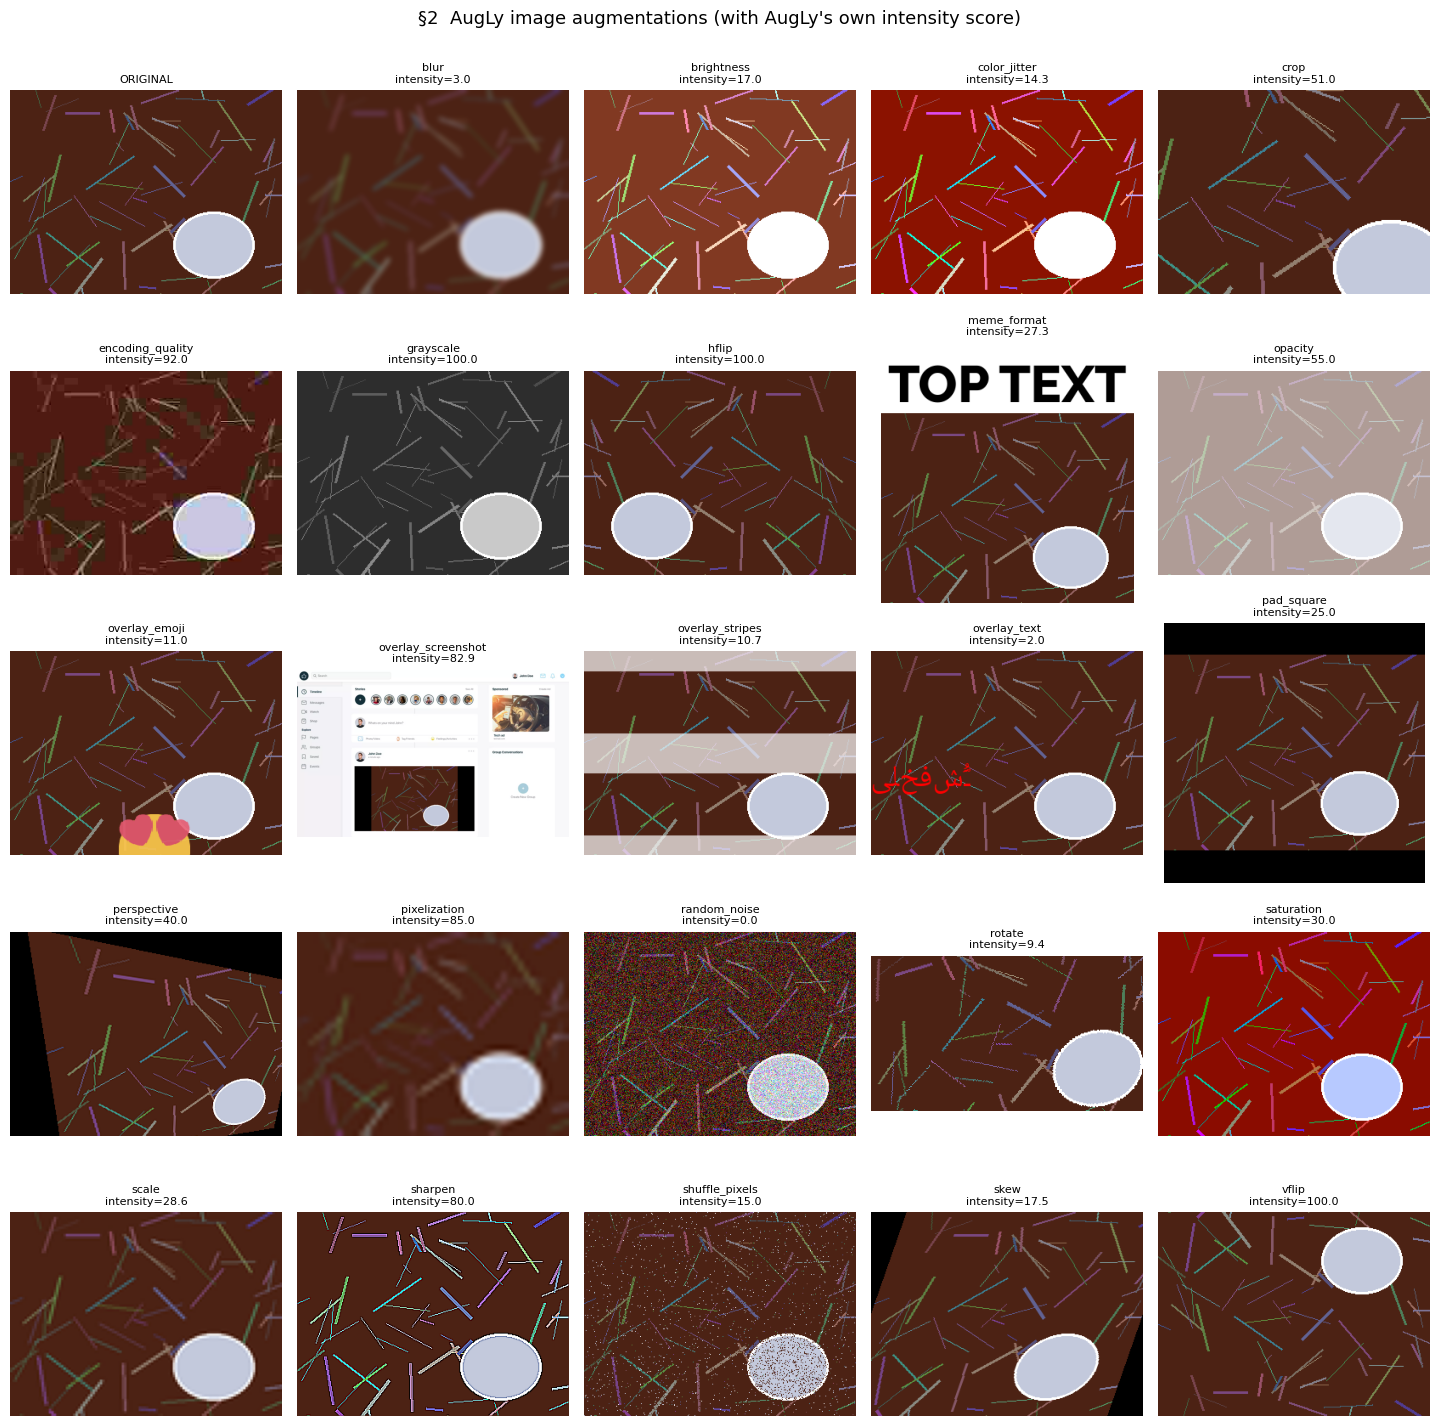

                   name  intensity  src_width  src_height  dst_width  dst_height
                  hflip 100.000000        320         240        320         240
              grayscale 100.000000        320         240        320         240
                  vflip 100.000000        320         240        320         240
       encoding_quality  92.000000        320         240        320         240
           pixelization  85.000000        320         240        320         240
overlay_onto_screenshot  82.869792        320         240       1200         736
                sharpen  80.000000        320         240        320         240
                opacity  55.000000        320         240        320         240
                   crop  51.000000        320         240        224         168
  perspective_transform  40.000000        320         240        320         240

### §3  COMPOSITION & REPRODUCIBILITY #######################################
same seed -> identical output:

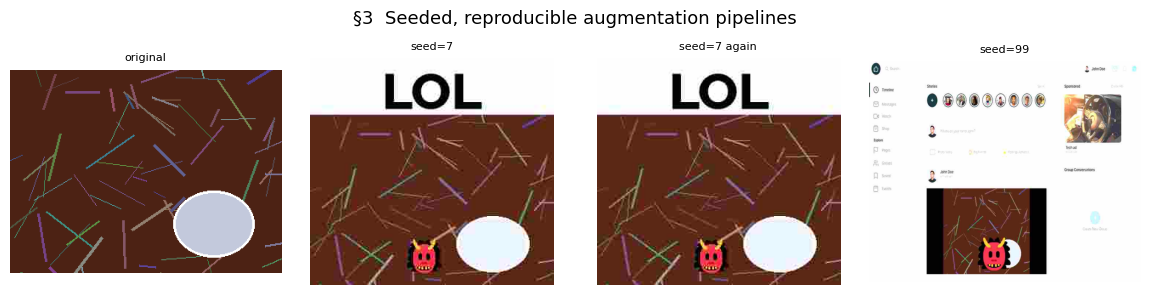


### §4  BBOX-AWARE AUGMENTATION #############################################
  crop         (192, 143, 287, 221) -> (160.0, 119.0, 255.0, 192)
  hflip        (192, 143, 287, 221) -> (33.0, 143.0, 128.0, 221.0)
  rotate 20    (192, 143, 287, 221) -> (138.0, 0, 255.0, 44.0)
  pad          (192, 143, 287, 221) -> (272.0, 203.0, 367.0, 281.0)
  meme_format  (192, 143, 287, 221) -> (192.0, 223.0, 287.0, 301.0)


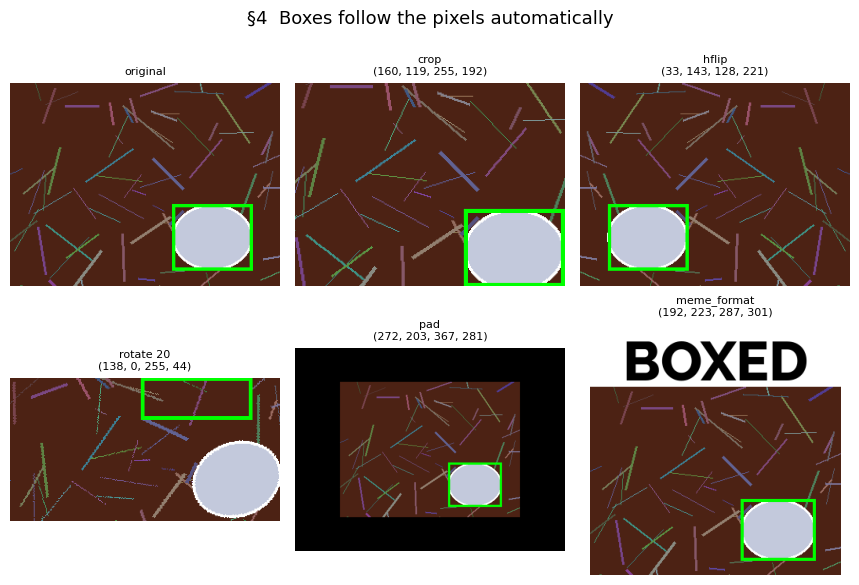


### §5  CUSTOM TRANSFORMS ###################################################


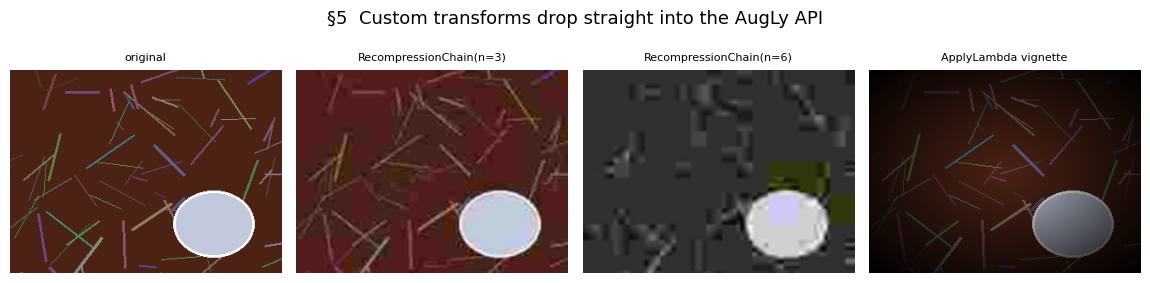

  custom metadata: {'name': 'recompression_chain', 'src_width': 320, 'src_height': 240, 'dst_width': 320, 'dst_height': 240, 'n_rounds': 3, 'qualities': [40, 19, 12], 'intensity': 76.33333333333333}
  composed with built-ins: OK

### §6  COPY-DETECTION ROBUSTNESS BENCHMARK #################################
           attack  top1_recall  mean_hamming  errors
            hflip        0.000        31.917       0
       screenshot        0.042        31.333       0
 perspective s=40        0.083        31.625       0
      meme format        0.250        24.417       0
        rotate 12        0.375        22.458       0
         crop 80%        0.583        20.375       0
REUPLOAD pipeline        0.917        11.042       0
         jpeg q=8        1.000         1.708       0
     pixelize 0.2        1.000         0.417       0
        grayscale        1.000         0.000       0
         blur r=3        1.000         0.375       0
    emoji overlay        1.000        11.917       0
   

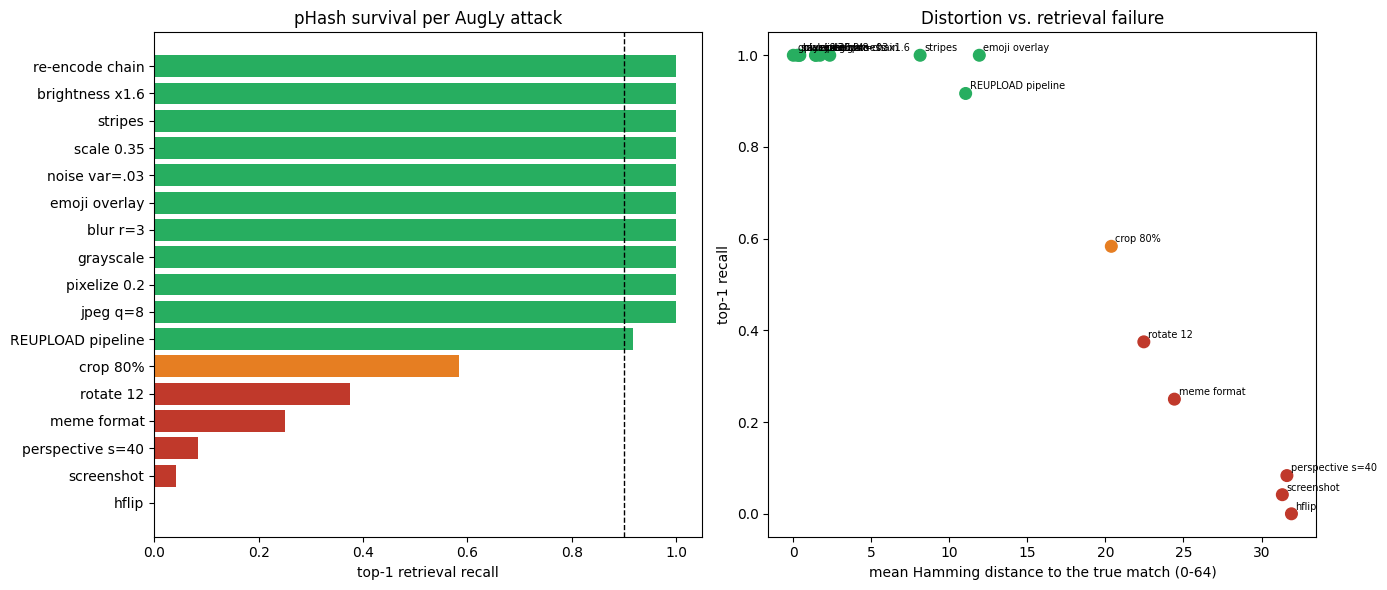


  pHash breaks under: ['hflip', 'screenshot', 'perspective s=40']
  -> exactly the augmentations you'd add to training, or handle with a
     geometry-invariant embedding instead of a hash.

### §7  TEXT ATTACK / DEFEND / HARDEN #######################################
clean test accuracy: 1.000

what the attacks look like on one sentence:
  typos (keyboard+misspell)  Ther qick brown fox jumps over the azy dog near teh riveg bank
  unicode homoglyphs         ₸he quİčk Ђ℟own fox jumps over Ꮖhe lazẎ ᚦog neaℛ thĒ ŗiveⓡ ᗿank
  leetspeak lookalikes       7he qu|[k!312own fox jumps over +he l@zy do9 ^ear th3 |2iver ba^k
  zero-width injection       Th⁤e qu‌ic‌k br​ow​n fo‌x ju​mp​s ov‌er th‌e la⁢zy do⁠g ne​ar th​e ri​ve
  punctuation injection      Th,e qu...ic...k br-ow.n fo!x ju'mp,s ov:er th?e la.zy do...g ne;ar th:e
  whitespace injection       The qui ck bro wn fox jumps ove r the lazy dog nea r the riv	er ban k
  fun fonts                  𝐓𝐡𝐞 𝐪𝐮𝐢𝐜𝐤 b͓̽r͓̽o͓̽w͓̽n͓̽ fox jumps over t̾h

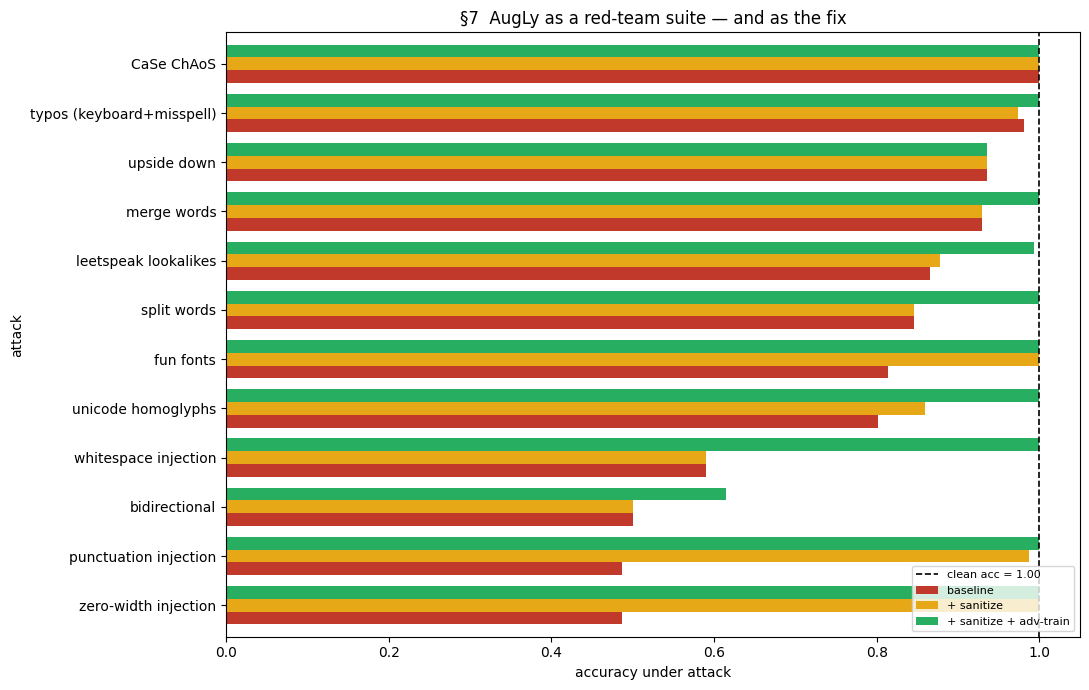


### §8  AUDIO AUGMENTATION ##################################################
  audio module unavailable (cannot import name 'sox_effects' from 'torchaudio' (/usr/local/lib/python3.13/dist-packages/torchaudio/__init__.py)).
  On Colab librosa/torch/torchaudio are preinstalled; elsewhere run:
    pip install "librosa>=0.8.1" soundfile audioread torch torchaudio

### §9  METADATA WAREHOUSE ##################################################
 source_id     augmentation  intensity  src_w  src_h  dst_w  dst_h  area_ratio
         0             blur       3.00    320    240    320    240        1.00
         0       brightness      17.00    320    240    320    240        1.00
         0     color_jitter      14.33    320    240    320    240        1.00
         0             crop      51.00    320    240    224    168        0.49
         0 encoding_quality      92.00    320    240    320    240        1.00
         0        grayscale     100.00    320    240    320    240        1.00
    

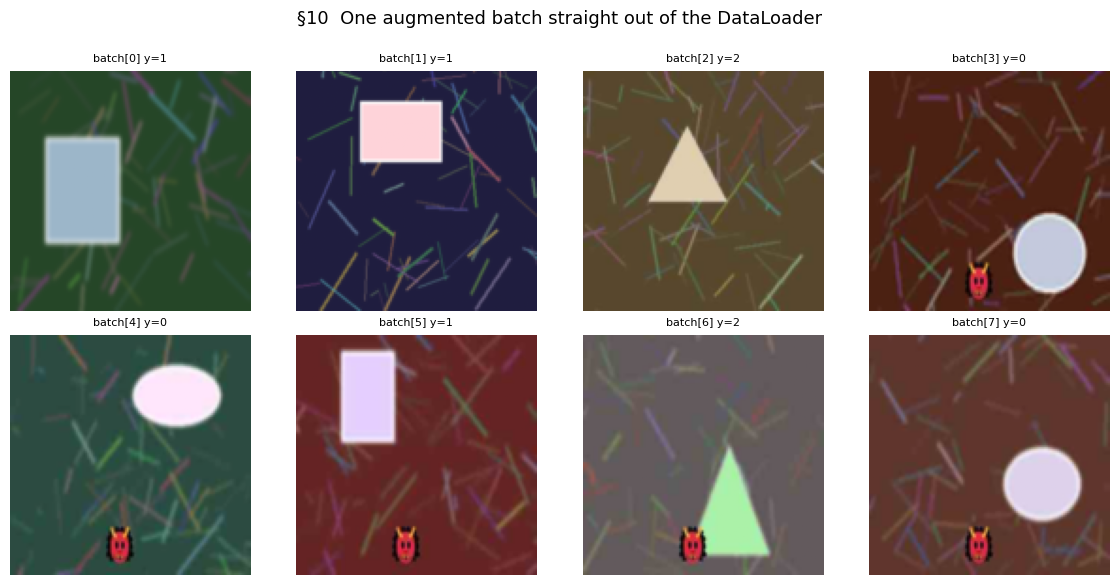

  aug_np_wrapper: (240, 320, 3) -> (240, 320, 3) (uint8)

DONE. Ideas from here:
  * swap pHash in §6 for a real embedding (CLIP / DINOv2) and re-run the table
  * feed §9's CSV into a curriculum: train on low-intensity augs first
  * add augly.video (pip install 'augly[video]' + apt install ffmpeg) and
    benchmark frame-level robustness the same way


In [1]:
print("\n### §10  PYTORCH DATASET / DATALOADER " + "#" * 39)
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    import torchvision.transforms as T

    class AugLyDataset(Dataset):
        """AugLy transforms are drop-in for torchvision because they are PIL->PIL."""

        def __init__(self, images, labels, train=True):
            self.images, self.labels = images, labels
            aug = imaugs.Compose([
                imaugs.OneOf([imaugs.RandomBlur(min_radius=0.5, max_radius=2.5),
                              imaugs.RandomPixelization(min_ratio=0.3, max_ratio=1.0),
                              imaugs.EncodingQuality(quality=20)], p=0.8),
                imaugs.RandomBrightness(min_factor=0.7, max_factor=1.4, p=0.6),
                imaugs.RandomEmojiOverlay(p=0.3),
                RecompressionChain(n_rounds=1, p=0.3),
            ])
            steps = ([aug] if train else []) + [
                T.Resize((128, 128)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
            self.tf = T.Compose(steps)

        def __len__(self):
            return len(self.images)

        def __getitem__(self, i):
            return self.tf(self.images[i]), self.labels[i]

    ds = AugLyDataset(IMAGES, [i % 3 for i in range(len(IMAGES))], train=True)
    dl = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0)
    xb, yb = next(iter(dl))
    print(f"  batch tensor {tuple(xb.shape)}  dtype={xb.dtype}  labels={yb.tolist()}")

    denorm = (xb[:8] * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
              + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)).clamp(0, 1)
    show_grid([(f"batch[{i}] y={yb[i].item()}", denorm[i].permute(1, 2, 0).numpy())
               for i in range(min(8, len(denorm)))],
              cols=4, title="§10  One augmented batch straight out of the DataLoader")

    np_img = np.asarray(DEMO_IMG)
    np_out = imaugs.aug_np_wrapper(np_img, imaugs.overlay_emoji,
                                   **{"opacity": 0.8, "y_pos": 0.4})
    print(f"  aug_np_wrapper: {np_img.shape} -> {np_out.shape} ({np_out.dtype})")

except ImportError:
    print("  torch/torchvision not installed — skipping (Colab has them by default).")

print("\n" + "=" * 78)
print("DONE. Ideas from here:")
print("  * swap pHash in §6 for a real embedding (CLIP / DINOv2) and re-run the table")
print("  * feed §9's CSV into a curriculum: train on low-intensity augs first")
print("  * add augly.video (pip install 'augly[video]' + apt install ffmpeg) and")
print("    benchmark frame-level robustness the same way")
print("=" * 78)